# Analisis Pola Deret Waktu PM2.5

- Stasioneritas (ADF Test)
- ACF / PACF
- Komponen tren & musiman
- Validasi kestabilan multi-horizon

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from supabase import create_client, Client
import os
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

In [2]:
SUPABASE_URL = os.getenv("SUPABASE_URL", "")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

if not SUPABASE_URL or not SUPABASE_KEY:
    env_path = "../.env"
    if os.path.exists(env_path):
        for line in open(env_path):
            if "=" in line and not line.startswith("#"):
                k, _, v = line.partition("=")
                os.environ[k.strip()] = v.strip().strip('"')
    SUPABASE_URL = os.getenv("SUPABASE_URL", "")
    SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Connected")

Connected


### 1. Ambil Data (14 hari terakhir)

In [3]:
TABLE = "tb_konsentrasi_gas"
days_back = 14
since = (datetime.now() - timedelta(days=days_back)).isoformat()

all_data = []
offset = 0
while True:
    resp = supabase.table(TABLE) \
        .select("pm25_ugm3,created_at") \
        .gte("created_at", since) \
        .order("created_at", desc=False) \
        .range(offset, offset + 999) \
        .execute()
    batch = resp.data
    if not batch:
        break
    all_data.extend(batch)
    offset += len(batch)

df = pd.DataFrame(all_data)
df["pm25_ugm3"] = pd.to_numeric(df["pm25_ugm3"], errors="coerce")
df["created_at"] = pd.to_datetime(df["created_at"]).dt.tz_localize(None)
df = df.dropna(subset=["pm25_ugm3"])
df = df.set_index("created_at").sort_index()
df = df[~df.index.duplicated(keep="first")]
df.rename(columns={"pm25_ugm3": "pm25"}, inplace=True)

print(f"Total: {len(df)} baris")
print(f"Rentang: {df.index[0]} s/d {df.index[-1]}")
print(f"Mean: {df['pm25'].mean():.2f}, Std: {df['pm25'].std():.2f}")
print(f"Min: {df['pm25'].min():.2f}, Max: {df['pm25'].max():.2f}")
print(f"Missing gaps: {df.index.to_series().diff().dt.total_seconds().gt(300).sum()}")

Total: 11764 baris
Rentang: 2026-03-30 12:25:56.915536 s/d 2026-04-09 14:13:11.911203
Mean: 170.41, Std: 152.23
Min: -9.61, Max: 427.47
Missing gaps: 11


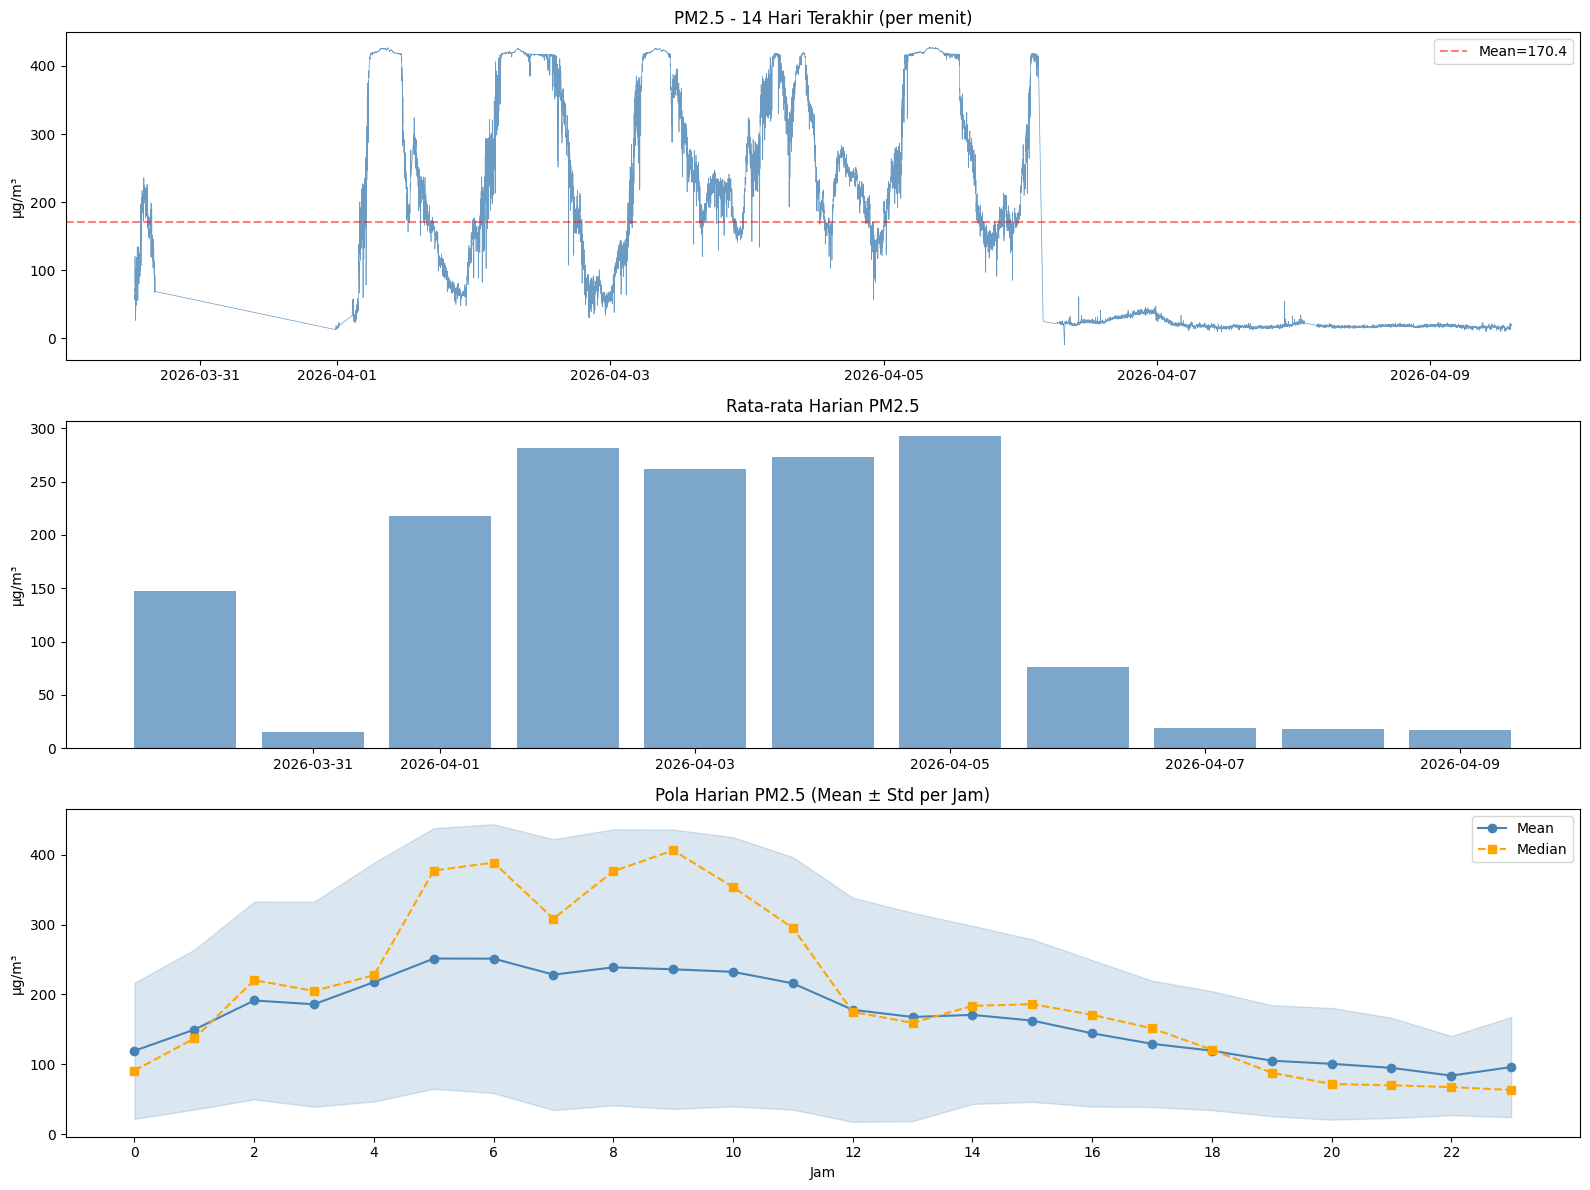

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(df.index, df["pm25"], linewidth=0.5, color="steelblue", alpha=0.8)
axes[0].set_title("PM2.5 - 14 Hari Terakhir (per menit)")
axes[0].set_ylabel("µg/m³")
axes[0].axhline(df["pm25"].mean(), color="red", linestyle="--", alpha=0.5, label=f"Mean={df['pm25'].mean():.1f}")
axes[0].legend()

daily = df.resample("D").mean()
axes[1].bar(daily.index, daily["pm25"], width=0.8, color="steelblue", alpha=0.7)
axes[1].set_title("Rata-rata Harian PM2.5")
axes[1].set_ylabel("µg/m³")

hourly = df.groupby(df.index.hour)["pm25"].agg(["mean", "std", "median"])
axes[2].fill_between(hourly.index, hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"], alpha=0.2, color="steelblue")
axes[2].plot(hourly.index, hourly["mean"], "o-", color="steelblue", label="Mean")
axes[2].plot(hourly.index, hourly["median"], "s--", color="orange", label="Median")
axes[2].set_title("Pola Harian PM2.5 (Mean ± Std per Jam)")
axes[2].set_xlabel("Jam")
axes[2].set_ylabel("µg/m³")
axes[2].legend()
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

### 2. Uji Stasioneritas (Augmented Dickey-Fuller)

In [5]:
series = df["pm25"].dropna()

print("=" * 60)
print("UJI STASIONERITAS (ADF Test)")
print("=" * 60)

for label, data in [("Level (mentah)", series),
                     ("Differencing 1", series.diff().dropna()),
                     ("Differencing 2", series.diff().diff().dropna())]:
    result = adfuller(data, autolag="AIC")
    stat = result[0]
    pval = result[1]
    crit = result[4]
    status = "STASIONER" if pval < 0.05 else "TIDAK STASIONER"
    print(f"\n{label}:")
    print(f"  ADF Statistic : {stat:.4f}")
    print(f"  p-value        : {pval:.6f}")
    print(f"  1% Critical   : {crit['1%']:.4f}")
    print(f"  5% Critical   : {crit['5%']:.4f}")
    print(f"  Status        : {status}")

UJI STASIONERITAS (ADF Test)

Level (mentah):
  ADF Statistic : -2.6227
  p-value        : 0.088386
  1% Critical   : -3.4309
  5% Critical   : -2.8618
  Status        : TIDAK STASIONER

Differencing 1:
  ADF Statistic : -14.7437
  p-value        : 0.000000
  1% Critical   : -3.4309
  5% Critical   : -2.8618
  Status        : STASIONER

Differencing 2:
  ADF Statistic : -30.7065
  p-value        : 0.000000
  1% Critical   : -3.4309
  5% Critical   : -2.8618
  Status        : STASIONER


### 3. ACF dan PACF

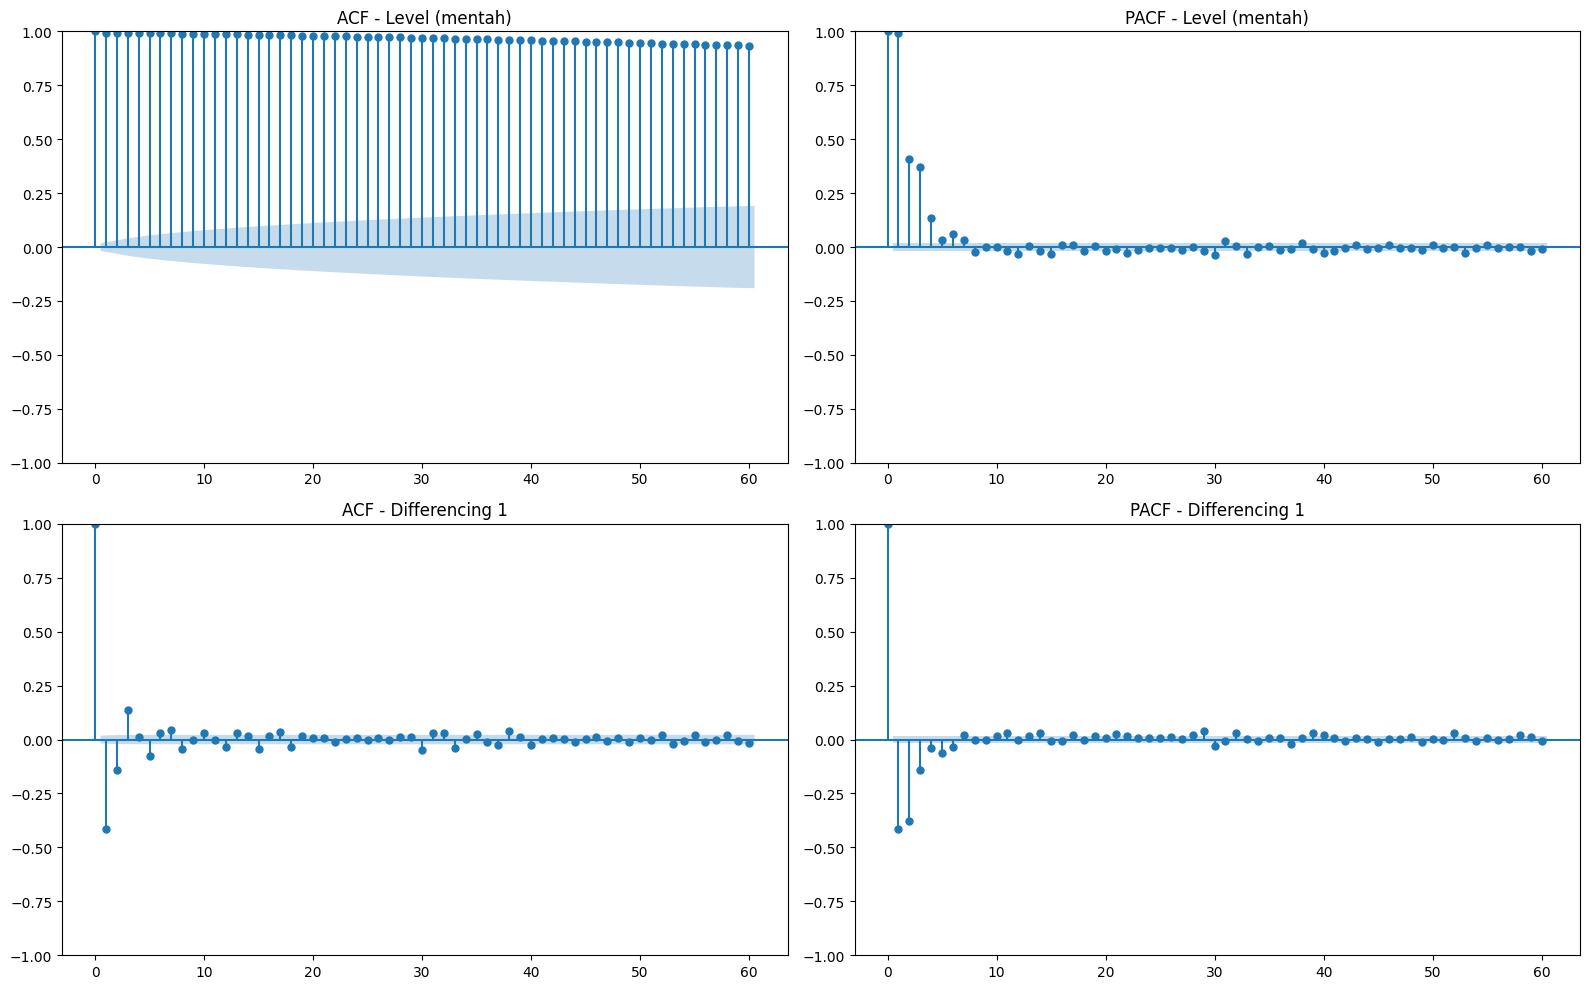

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

lags = 60

plot_acf(series, lags=lags, ax=axes[0, 0], title="ACF - Level (mentah)")
plot_pacf(series, lags=min(60, len(series) // 3), ax=axes[0, 1], title="PACF - Level (mentah)")

diff1 = series.diff().dropna()
plot_acf(diff1, lags=lags, ax=axes[1, 0], title="ACF - Differencing 1")
plot_pacf(diff1, lags=min(60, len(diff1) // 3), ax=axes[1, 1], title="PACF - Differencing 1")

plt.tight_layout()
plt.show()

In [7]:
print("\n" + "=" * 60)
print("ANALISIS ACF/PACF")
print("=" * 60)

acf_vals = acf(series, nlags=30, fft=True)
print(f"\nACF signifikan (lag):", [i for i in range(1, 16) if acf_vals[i] > 0.05 or acf_vals[i] < -0.05])

pacf_vals = pacf(series, nlags=30)
print(f"PACF signifikan (lag):", [i for i in range(1, 16) if abs(pacf_vals[i]) > 0.05])

print(f"\nAutokorelasi lag-1 : {acf_vals[1]:.4f} (strong: >0.5)")
print(f"Autokorelasi lag-5 : {acf_vals[5]:.4f}")
print(f"Autokorelasi lag-60: {acf_vals[min(60, len(acf_vals)-1)]:.4f}")


ANALISIS ACF/PACF

ACF signifikan (lag): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
PACF signifikan (lag): [1, 2, 3, 4, 6]

Autokorelasi lag-1 : 0.9939 (strong: >0.5)
Autokorelasi lag-5 : 0.9912
Autokorelasi lag-60: 0.9690


### 4. Dekomposisi Musiman

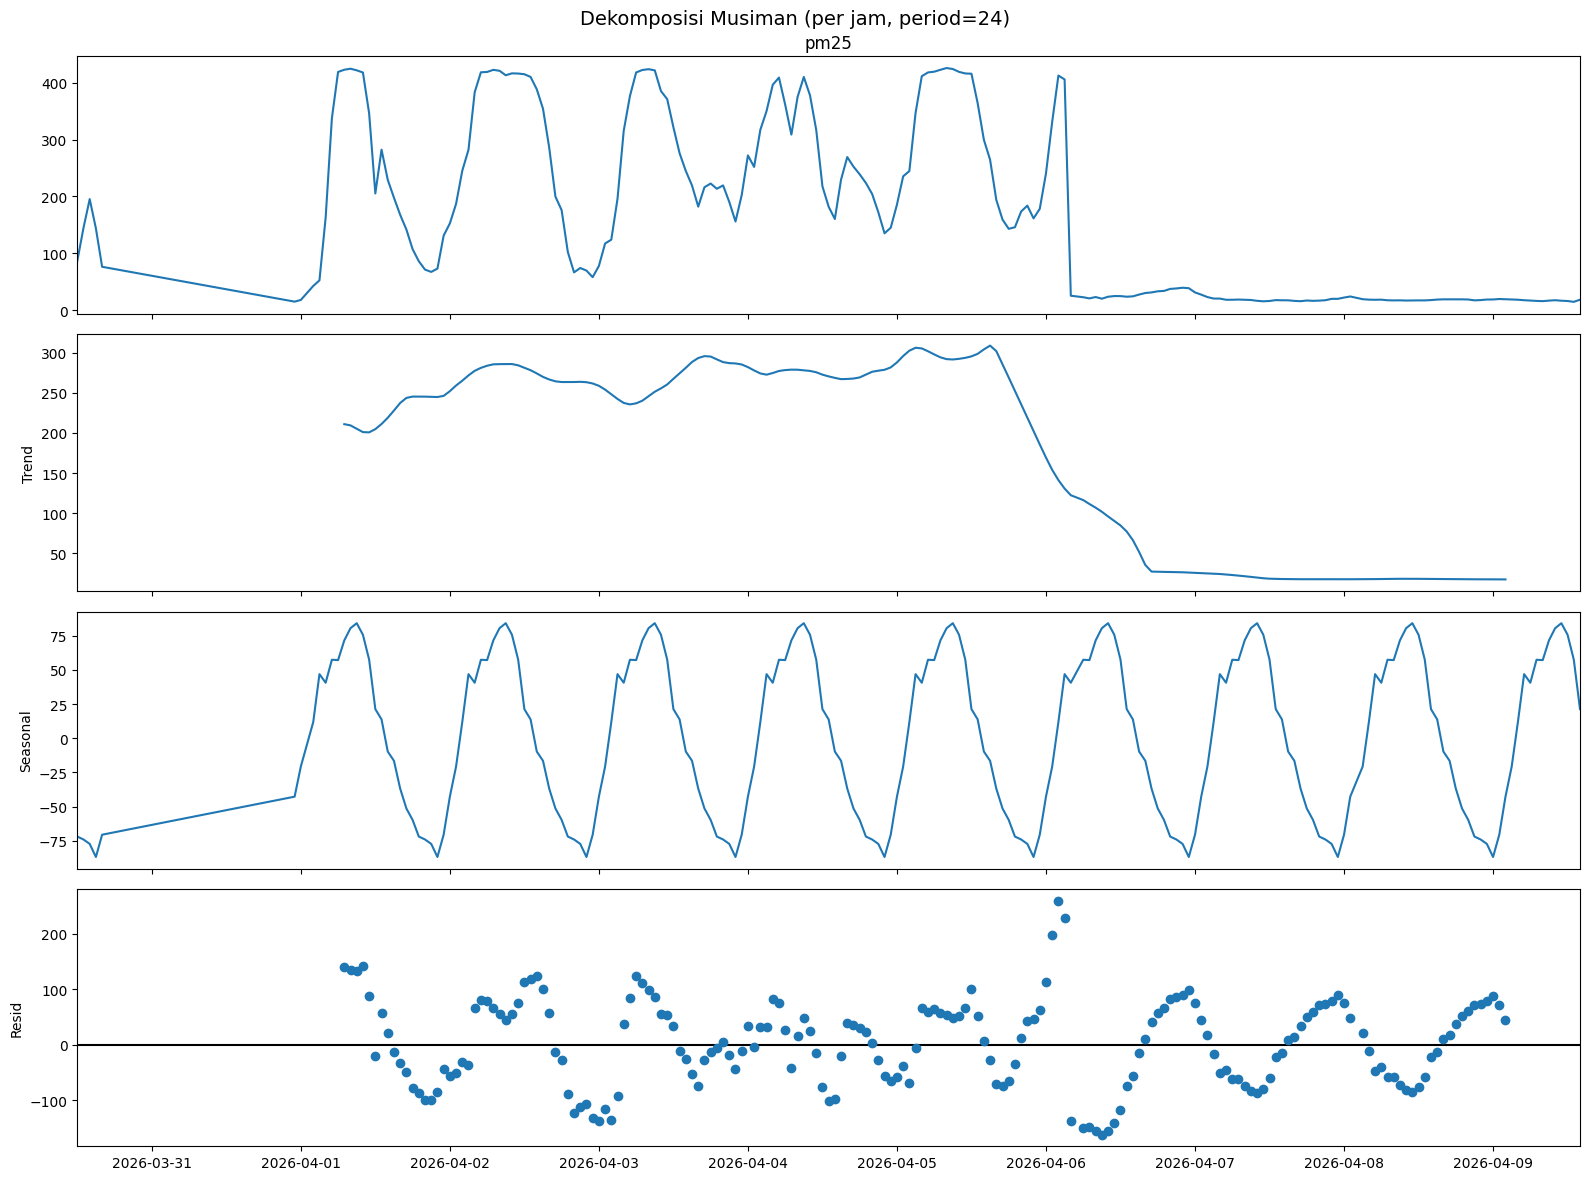

In [8]:
resampled = df["pm25"].resample("H").mean().dropna()

if len(resampled) >= 48:
    decomp = seasonal_decompose(resampled, model="additive", period=24)
    fig = decomp.plot()
    fig.set_size_inches(16, 12)
    plt.suptitle("Dekomposisi Musiman (per jam, period=24)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Data terlalu sedikit untuk dekomposisi (butuh >= 48 jam)")

### 5. Stabilitas Multi-Horizon

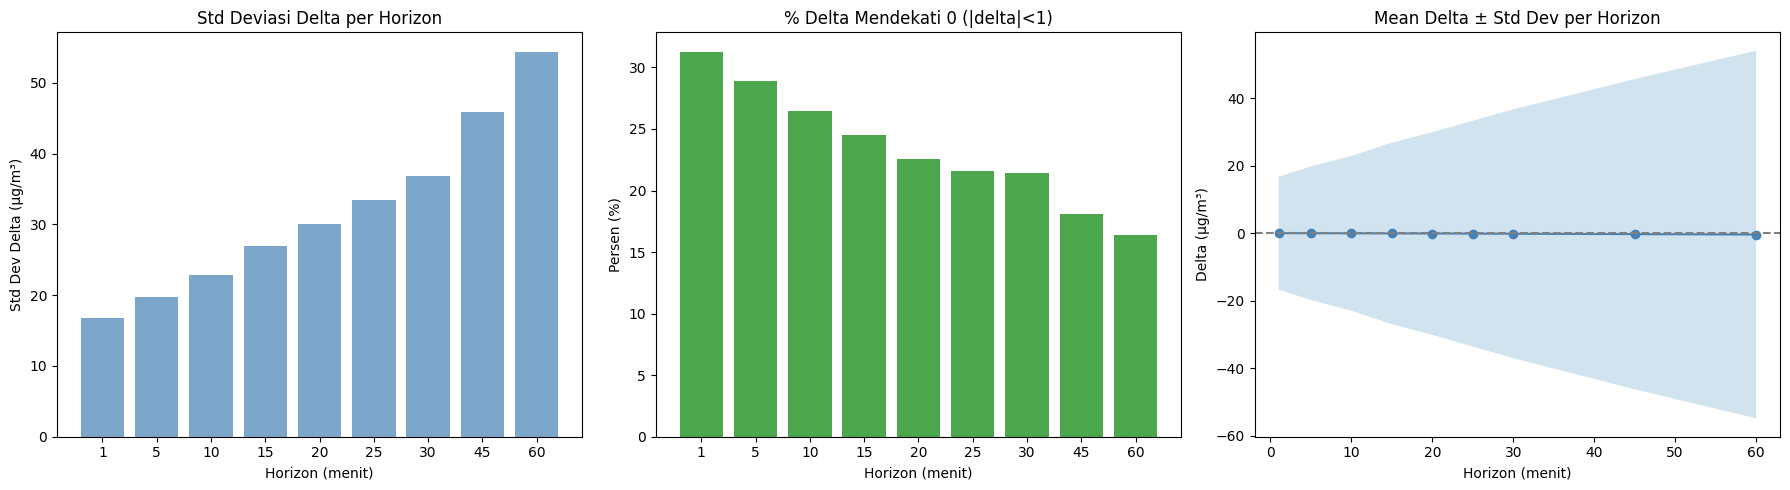

In [9]:
HORIZONS = [1, 5, 10, 15, 20, 25, 30, 45, 60]

series = df["pm25"].dropna()
results = []

for h in HORIZONS:
    actual = series.shift(-h)
    current = series
    delta = actual - current
    valid = delta.dropna()

    if len(valid) > 0:
        results.append({
            "horizon": h,
            "n": len(valid),
            "delta_mean": valid.mean(),
            "delta_std": valid.std(),
            "delta_min": valid.min(),
            "delta_max": valid.max(),
            "pct_zero": (abs(valid) < 1).mean() * 100,
            "autocorr_delta": valid.autocorr() if len(valid) > 10 else 0,
        })

rdf = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(rdf["horizon"].astype(str), rdf["delta_std"], color="steelblue", alpha=0.7)
axes[0].set_title("Std Deviasi Delta per Horizon")
axes[0].set_xlabel("Horizon (menit)")
axes[0].set_ylabel("Std Dev Delta (µg/m³)")

axes[1].bar(rdf["horizon"].astype(str), rdf["pct_zero"], color="green", alpha=0.7)
axes[1].set_title("% Delta Mendekati 0 (|delta|<1)")
axes[1].set_xlabel("Horizon (menit)")
axes[1].set_ylabel("Persen (%)")

axes[2].plot(rdf["horizon"], rdf["delta_mean"], "o-", color="steelblue")
axes[2].fill_between(rdf["horizon"], rdf["delta_mean"] - rdf["delta_std"], rdf["delta_mean"] + rdf["delta_std"], alpha=0.2)
axes[2].axhline(0, color="gray", linestyle="--")
axes[2].set_title("Mean Delta ± Std Dev per Horizon")
axes[2].set_xlabel("Horizon (menit)")
axes[2].set_ylabel("Delta (µg/m³)")

plt.tight_layout()
plt.show()

In [10]:
print("\n" + "=" * 60)
print("KESTABILAN MULTI-HORIZON")
print("=" * 60)
print(rdf.to_string(index=False))

print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)

adf_pval = adfuller(series)[1]
acf_lag1 = acf(series, nlags=1, fft=True)[1]
pacf_sig = [i for i in range(1, 16) if abs(pacf(series, nlags=15)[i]) > 0.05]

print(f"\n1. Stasioneritas: p-value ADF = {adf_pval:.6f}")
if adf_pval < 0.05:
    print("   -> Data STASIONER, bisa langsung dimodelkan tanpa differencing")
else:
    print("   -> Data TIDAK STASIONER, perlu differencing d=1")

print(f"\n2. ACF lag-1 = {acf_lag1:.4f}")
if acf_lag1 > 0.7:
    print("   -> Autokorelasi tinggi, data sangat bergantung pada nilai sebelumnya")
    print("   -> Model AR / lag-based (XGBoost) cocok")
elif acf_lag1 > 0.3:
    print("   -> Autokorelasi moderat")
else:
    print("   -> Autokorelasi rendah, data hampir random")

print(f"\n3. PACF signifikan di lag: {pacf_sig}")
if pacf_sig:
    print(f"   -> Orde AR sementara: p = {max(pacf_sig)}")

print(f"\n4. Horizon 30 menit:")
h30 = rdf[rdf["horizon"] == 30].iloc[0]
print(f"   Std dev delta: {h30['delta_std']:.2f} µg/m³")
print(f"   % hampir nol:  {h30['pct_zero']:.1f}%")
if h30['delta_std'] < 5:
    print("   -> Prediksi 30 menit relatif stabil, model delta feasible")
else:
    print("   -> Variasi 30 menit besar, prediksi multi-step menantang")
    print("   -> Pertimbangkan recursive short-step atau ensemble")


KESTABILAN MULTI-HORIZON
 horizon     n  delta_mean  delta_std  delta_min  delta_max  pct_zero  autocorr_delta
       1 11763   -0.003566  16.707304    -388.97     178.00 31.284536       -0.413662
       5 11759   -0.019081  19.799418    -391.61     196.15 28.880007        0.233721
      10 11754   -0.056216  22.905592    -393.20     179.41 26.433555        0.485400
      15 11749   -0.072996  26.875480    -392.67     281.63 24.470168        0.596963
      20 11744   -0.102651  30.003607    -394.25     233.52 22.598774        0.692805
      25 11739   -0.135949  33.426405    -394.78     307.89 21.586166        0.749722
      30 11734   -0.174758  36.851427    -394.60     304.36 21.416397        0.785065
      45 11719   -0.290168  45.919710    -396.72     337.15 18.073214        0.868349
      60 11704   -0.404710  54.412630    -413.11     339.97 16.379016        0.904472

KESIMPULAN

1. Stasioneritas: p-value ADF = 0.088386
   -> Data TIDAK STASIONER, perlu differencing d=1

2. ACF l

### 6. Evaluasi Model XGBoost 1-Step (PKL)

In [ ]:
import joblib
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

pkl_path = "../ml_model/xgb_pm25.pkl"
if not os.path.exists(pkl_path):
    print(f"PKL tidak ditemukan: {pkl_path}")
else:
    model = joblib.load(pkl_path)
    print(f"Model loaded: {type(model).__name__}")
    print(f"Feature names ({len(model.feature_names_in_)}): {list(model.feature_names_in_)}")

    RAW_COLS2 = ["pm2.5", "pm10_ugm3", "co_ugm3", "no2_ugm3", "temperature", "humidity"]

    feat = df.copy()
    for col in RAW_COLS2:
        feat[f"{col}_lag_1min"] = feat[col].shift(1)
        feat[f"{col}_lag_5min"] = feat[col].shift(5)
        feat[f"{col}_lag_15min"] = feat[col].shift(15)
        feat[f"{col}_lag_60min"] = feat[col].shift(60)
        feat[f"{col}_rolling_mean_5min"] = feat[col].rolling(5).mean()
        feat[f"{col}_rolling_std_5min"] = feat[col].rolling(5).std()
        feat[f"{col}_rolling_mean_15min"] = feat[col].rolling(15).mean()

    feat["minute"] = feat.index.minute
    feat["hour"] = feat.index.hour
    feat["dayofweek"] = feat.index.dayofweek
    feat["target"] = feat["pm2.5"].shift(-1)
    feat = feat.dropna()

    feature_cols_model = list(model.feature_names_in_)
    missing = [c for c in feature_cols_model if c not in feat.columns]
    extra = [c for c in feat.columns if c not in feature_cols_model and c != "target"]

    print(f"\nFitur tersedia: {len(feat.columns) - 1}")
    print(f"Fitur model butuhkan: {len(feature_cols_model)}")
    if missing:
        print(f"  Missing: {missing}")
    if extra:
        print(f"  Extra (tidak dipakai model): {extra}")

    if not missing:
        split_idx = int(len(feat) * 0.8)
        X_train = feat.iloc[:split_idx][feature_cols_model]
        y_train = feat.iloc[:split_idx]["target"]
        X_test = feat.iloc[split_idx:][feature_cols_model]
        y_test = feat.iloc[split_idx:]["target"]

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        print(f"\n{'='*60}")
        print(f"EVALUASI MODEL XGBOOST 1-STEP (PKL)")
        print(f"{'='*60}")
        print(f"  Data      : {len(feat)} baris")
        print(f"  Train     : {len(X_train)}")
        print(f"  Test      : {len(X_test)}")
        print(f"  MAE       : {mae:.4f} µg/m³")
        print(f"  RMSE      : {rmse:.4f} µg/m³")
        print(f"  R²        : {r2:.4f} ({r2*100:.2f}%)")
        print(f"  MAPE      : {mape:.2f}%")
        print(f"\n  -> Copy nilai di bawah ke MLForecastPrototype.tsx")
        print(f"     MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}, R2={r2:.2f}")